# ============================================================
# INDIAN SIGN LANGUAGE (ISL) SENTENCE CLASSIFICATION
# COMPLETE TRAINING PIPELINE
# MediaPipe Tasks API Version
# PyTorch Edition — Optimized for NVIDIA GPU / Windows
# ============================================================

## Setup Instructions

### 1. Install PyTorch with CUDA support
Visit https://pytorch.org/get-started/locally/ and select your CUDA version.
Example for CUDA 12.1:
```
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install mediapipe opencv-python scikit-learn tqdm matplotlib
```

### 2. Download MediaPipe model files and place in the same folder as this notebook:
- **hand_landmarker.task** → https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
- **pose_landmarker_full.task** → https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task

In [3]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm
import mediapipe as mp
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [4]:
# ============================================================
# GPU SETUP & VERIFICATION
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ Found {torch.cuda.device_count()} GPU(s):")
    for i in range(torch.cuda.device_count()):
        print(f"   [{i}] {torch.cuda.get_device_name(i)}")

elif torch.backends.mps.is_available():
    device = torch.device("mps")

    print("✓ Apple Silicon GPU detected (MPS)")
    print("   Using Metal Performance Shaders backend")

else:
    device = torch.device("cpu")
    print("⚠ No GPU detected — running on CPU.")
    print("  Make sure CUDA and cuDNN are installed and the correct torch+cu build is used.")

print(f"\nPyTorch version : {torch.__version__}")
print(f"Using device    : {device}")

✓ Apple Silicon GPU detected (MPS)
   Using Metal Performance Shaders backend

PyTorch version : 2.10.0
Using device    : mps


In [5]:
# ============================================================
# DATASET PATH
# ============================================================

DATA_DIR = Path(
    "isl_nmf/data/isl_csltr/ISL_CSLRT_Corpus/ISL_CSLRT_Corpus/Videos_Sentence_Level"
)

# ============================================================
# CONFIG
# ============================================================

SEQ_LEN = 30

# pose (33*3) + left hand (21*3) + right hand (21*3)
NUM_KEYPOINTS = 225

FRAME_SKIP = 5

# Increase batch size for GPU — 8 is too small and wastes GPU throughput
BATCH_SIZE = 32

HAND_MODEL = "hand_landmarker.task"
POSE_MODEL = "pose_landmarker_full.task"

In [6]:
# ============================================================
# MEDIAPIPE TASKS API
# ============================================================

# NOTE: MediaPipe runs on CPU only (it does not use your NVIDIA GPU).
# This is fine — keypoint extraction is a preprocessing step.
# Results are cached to disk so you only do it once.

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

hand_options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=HAND_MODEL),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2
)

pose_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=POSE_MODEL),
    running_mode=VisionRunningMode.IMAGE
)

hand_detector = HandLandmarker.create_from_options(hand_options)
pose_detector = PoseLandmarker.create_from_options(pose_options)

print("✓ MediaPipe Tasks models loaded")

I0000 00:00:1778513870.381917 2165315 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
I0000 00:00:1778513870.499144 2165315 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778513870.520721 2165318 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778513870.562676 2165325 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1778513870.634541 2165328 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1778513870.709980 2165331 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✓ MediaPipe Tasks models loaded


W0000 00:00:1778513871.044532 2165330 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [7]:
# ============================================================
# LOAD CLASS NAMES
# ============================================================

class_names = sorted([
    d.name
    for d in DATA_DIR.iterdir()
    if d.is_dir()
])

print(f"Total Classes: {len(class_names)}")
print(class_names[:10])

Total Classes: 101
['He is going into the room', 'No need to worry dont worry', 'This place is beautiful', 'are you free today', 'are you hiding something', 'bring water for me', 'can i help you', 'can you repeat that please', 'comb your hair', 'congratulations']


In [8]:
# ============================================================
# EXTRACT KEYPOINTS FROM A SINGLE FRAME
# ============================================================

def extract_keypoints(frame):

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # ---- POSE ----
    pose_result = pose_detector.detect(mp_image)
    pose = np.zeros(33 * 3)

    if pose_result.pose_landmarks:
        pose_landmarks = pose_result.pose_landmarks[0]
        pose = np.array([
            [lm.x, lm.y, lm.z]
            for lm in pose_landmarks
        ]).flatten()

    # ---- HANDS ----
    hand_result = hand_detector.detect(mp_image)
    left_hand  = np.zeros(21 * 3)
    right_hand = np.zeros(21 * 3)

    if hand_result.hand_landmarks:
        for idx, hand_landmarks in enumerate(hand_result.hand_landmarks):

            handedness = (
                hand_result.handedness[idx][0].category_name
            )

            hand_array = np.array([
                [lm.x, lm.y, lm.z]
                for lm in hand_landmarks
            ]).flatten()

            if handedness == "Left":
                left_hand = hand_array
            else:
                right_hand = hand_array

    # ---- CONCATENATE ----
    keypoints = np.concatenate([pose, left_hand, right_hand])

    return keypoints


# ============================================================
# LOAD ONE VIDEO → FIXED-LENGTH SEQUENCE
# ============================================================

def load_video(video_path):

    cap = cv2.VideoCapture(str(video_path))

    frames = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1

        if frame_idx % FRAME_SKIP != 0:
            continue

        keypoints = extract_keypoints(frame)
        frames.append(keypoints)

    cap.release()

    if len(frames) == 0:
        return None

    frames = np.array(frames)

    # ---- FIX SEQUENCE LENGTH ----

    if len(frames) > SEQ_LEN:
        # Uniformly sample SEQ_LEN frames
        idx = np.linspace(0, len(frames) - 1, SEQ_LEN).astype(int)
        frames = frames[idx]

    elif len(frames) < SEQ_LEN:
        # Pad at end with zeros
        padding = np.zeros((SEQ_LEN - len(frames), NUM_KEYPOINTS))
        frames = np.concatenate([frames, padding])

    return frames.astype(np.float32)  # cast to float32 early to save RAM

In [9]:
# ============================================================
# BUILD DATASET (with caching)
# ============================================================

X = []
y = []

# Handle .avi and .mov which are common in sign language datasets
video_extensions = [".mp4", ".MP4", ".avi", ".AVI", ".mov", ".MOV"]

cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

for class_name in class_names:

    class_dir = DATA_DIR / class_name

    video_files = []
    for ext in video_extensions:
        video_files.extend(class_dir.glob(f"*{ext}"))

    print(f"\n{class_name}: {len(video_files)} videos")

    for video_path in tqdm(video_files):

        try:
            safe_name = (
                class_name.replace(" ", "_")
                + "_"
                + video_path.stem.replace(" ", "_")
            )
            cache_path = cache_dir / f"{safe_name}.npy"

            if cache_path.exists():
                sequence = np.load(cache_path)
            else:
                sequence = load_video(video_path)
                if sequence is not None:
                    np.save(cache_path, sequence)

            if sequence is not None:
                X.append(sequence)
                y.append(class_name)

        except Exception as e:
            print(f"\nError processing: {video_path}")
            print(e)

print("\n✓ Feature extraction completed")

# ============================================================
# CONVERT TO NUMPY
# ============================================================

X = np.array(X, dtype=np.float32)  # explicit dtype
y = np.array(y)

print("\nDataset Shape:")
print(X.shape)
print(y.shape)


He is going into the room: 7 videos


100%|██████████| 7/7 [00:00<00:00, 1011.41it/s]



No need to worry dont worry: 1 videos


100%|██████████| 1/1 [00:00<00:00, 338.28it/s]



This place is beautiful: 7 videos


...


you do anything, i do not care: 6 videos


100%|██████████| 6/6 [00:00<00:00, 1718.27it/s]



you need a medicine, take this one: 7 videos


100%|██████████| 7/7 [00:00<00:00, 1398.03it/s]



✓ Feature extraction completed

Dataset Shape:
(687, 30, 225)
(687,)


In [12]:
# ============================================================
# ENCODE LABELS
# ============================================================
from collections import Counter
import numpy as np

counts = Counter(y)

valid_classes = [cls for cls, cnt in counts.items() if cnt >= 2]

mask = np.isin(y, valid_classes)

X = X[mask]
y = y[mask]

print("Filtered dataset shape:", X.shape)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Save the encoder so you can decode predictions later
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)
print("✓ Label encoder saved as label_encoder.pkl")

# ============================================================
# TRAIN / TEST SPLIT
# Use stratify to ensure all classes appear in both splits
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_encoded   # critical for small datasets
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ============================================================
# CONVERT TO PYTORCH TENSORS & BUILD DATALOADERS
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)#True for Cuda
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print("\n✓ DataLoaders ready")
print(f"  Train batches : {len(train_loader)}")
print(f"  Test  batches : {len(test_loader)}")

Filtered dataset shape: (685, 30, 225)
✓ Label encoder saved as label_encoder.pkl

Train Shape: (548, 30, 225)
Test Shape : (137, 30, 225)

✓ DataLoaders ready
  Train batches : 18
  Test  batches : 5


In [13]:
# ============================================================
# BUILD MODEL
# Mirrors the original: 2x Bidirectional LSTM → BN → Dense(256) → Dense(128) → Softmax
# ============================================================

class ISLModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout1=0.3, dropout2=0.4, dropout3=0.3):
        super(ISLModel, self).__init__()

        # First Bidirectional LSTM (return_sequences=True → batch_first=True, outputs all timesteps)
        self.bilstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.dropout1 = nn.Dropout(dropout1)

        # Second Bidirectional LSTM (return_sequences=False → take last output)
        self.bilstm2 = nn.LSTM(
            input_size=hidden_size * 2,   # *2 because bidirectional
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # BatchNorm over the flattened BiLSTM output (hidden_size * 2)
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)

        # Dense layers
        self.fc1     = nn.Linear(hidden_size * 2, 256)
        self.relu1   = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout2)

        self.fc2     = nn.Linear(256, 128)
        self.relu2   = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout3)

        self.out = nn.Linear(128, num_classes)
        # Note: CrossEntropyLoss includes Softmax internally

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.bilstm1(x)          # (batch, seq_len, hidden*2)
        out = self.dropout1(out)

        out, _ = self.bilstm2(out)         # (batch, seq_len, hidden*2)
        out = out[:, -1, :]               # take last timestep → (batch, hidden*2)

        out = self.batch_norm(out)

        out = self.dropout2(self.relu1(self.fc1(out)))
        out = self.dropout3(self.relu2(self.fc2(out)))
        out = self.out(out)

        return out


model = ISLModel(
    input_size=NUM_KEYPOINTS,
    hidden_size=128,
    num_classes=len(class_names)
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

ISLModel(
  (bilstm1): LSTM(225, 128, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (bilstm2): LSTM(256, 128, batch_first=True, bidirectional=True)
  (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (dropout3): Dropout(p=0.3, inplace=False)
  (out): Linear(in_features=128, out_features=101, bias=True)
)

Total trainable parameters: 871,013


In [15]:
# ============================================================
# COMPILE MODEL  (loss + optimizer)
# ============================================================

criterion = nn.CrossEntropyLoss()          # equivalent to categorical_crossentropy + softmax
optimizer = optim.Adam(model.parameters(), lr=1e-3)   # start at 1e-3, let ReduceLR handle decay

# ReduceLROnPlateau — mirrors Keras callback
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    #verbose=True
)

print("✓ Loss, optimizer, and scheduler configured")

✓ Loss, optimizer, and scheduler configured


In [11]:
# ============================================================
# TRAINING LOOP
# Mirrors Keras model.fit() with EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
# ============================================================

EPOCHS       = 100
PATIENCE     = 15   # EarlyStopping patience (was 10, bumped for 101-class task)
BEST_CKPT    = "isl_best_model.pt"

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc   = 0.0
patience_count = 0


def run_epoch(loader, training=True):
    """One forward pass over a DataLoader. Returns (avg_loss, accuracy)."""
    if training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss   = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == yb).sum().item()
            total      += xb.size(0)

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(test_loader,  training=False)

    # Step scheduler on val_loss (mirrors Keras ReduceLROnPlateau)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:3d}/{EPOCHS}  "
        f"loss={train_loss*100:.4f}  acc={train_acc*100:.4f}  "
        f"val_loss={val_loss*100:.4f}  val_acc={val_acc*100:.4f}  "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    # ModelCheckpoint — save best val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  ✓ Best checkpoint saved  (val_acc={best_val_acc*100:.4f})")
        patience_count = 0
    else:
        patience_count += 1

    # EarlyStopping
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

# Restore best weights (mirrors restore_best_weights=True)
model.load_state_dict(torch.load(BEST_CKPT))
print("\n✓ Training complete — best weights restored")

Epoch   1/100  loss=4.5918  acc=0.0109  val_loss=4.5660  val_acc=0.0145  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0145)
Epoch   2/100  loss=4.4829  acc=0.0173  val_loss=4.4284  val_acc=0.0327  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0327)
Epoch   3/100  loss=4.4166  acc=0.0218  val_loss=4.3624  val_acc=0.0255  lr=1.00e-03
Epoch   4/100  loss=4.3809  acc=0.0191  val_loss=4.3669  val_acc=0.0145  lr=1.00e-03
Epoch   5/100  loss=4.3138  acc=0.0282  val_loss=4.3039  val_acc=0.0364  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0364)
Epoch   6/100  loss=4.2404  acc=0.0291  val_loss=4.2548  val_acc=0.0327  lr=1.00e-03
Epoch   7/100  loss=4.2221  acc=0.0346  val_loss=4.1948  val_acc=0.0327  lr=1.00e-03
Epoch   8/100  loss=4.1381  acc=0.0500  val_loss=4.1630  val_acc=0.0364  lr=1.00e-03
Epoch   9/100  loss=4.0230  acc=0.0464  val_loss=4.0863  val_acc=0.0582  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0582)
Epoch  10/100  loss=3.9898  acc=0.0601  val_loss=4.0595  va

C:\Users\Sh.Pritpal Singh\AppData\Local\Temp\ipykernel_24564\2559312233.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_CKPT))


In [12]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

torch.save(model.state_dict(), "isl_sentence_model.pt")
print("✓ Model saved as isl_sentence_model.pt")
print("  (Best checkpoint also saved as isl_best_model.pt)")

# ============================================================
# EVALUATE
# ============================================================

_, test_acc = run_epoch(test_loader, training=False)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

✓ Model saved as isl_sentence_model.pt
  (Best checkpoint also saved as isl_best_model.pt)

Test Accuracy: 73.09%


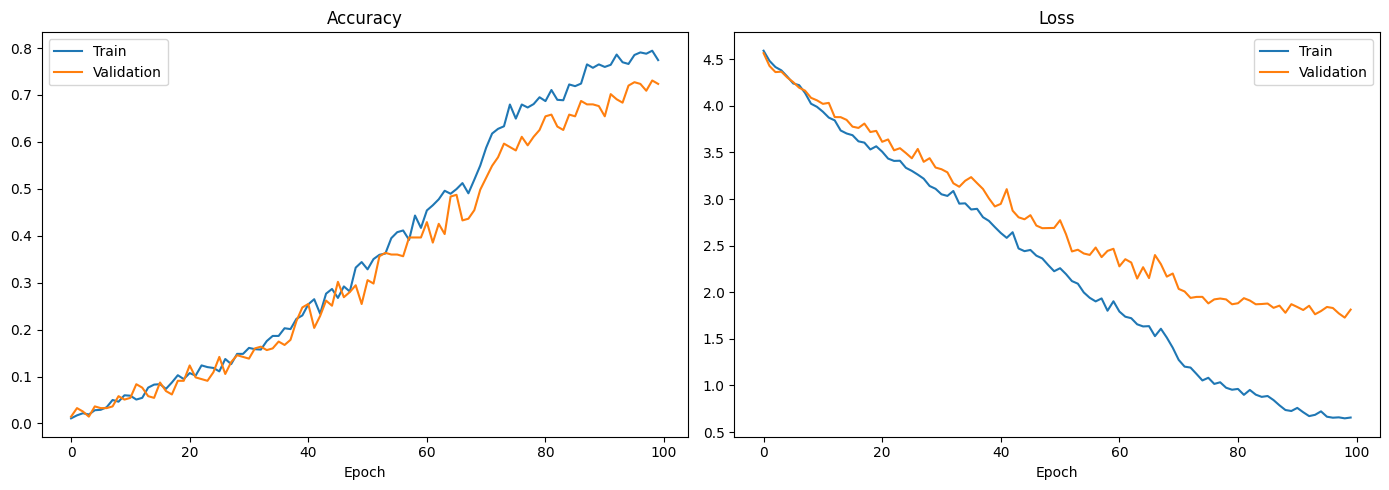

✓ Training plot saved as training_history.png


In [13]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_acc'], label='Train')
ax1.plot(history['val_acc'],   label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_loss'], label='Train')
ax2.plot(history['val_loss'],   label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("✓ Training plot saved as training_history.png")